In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

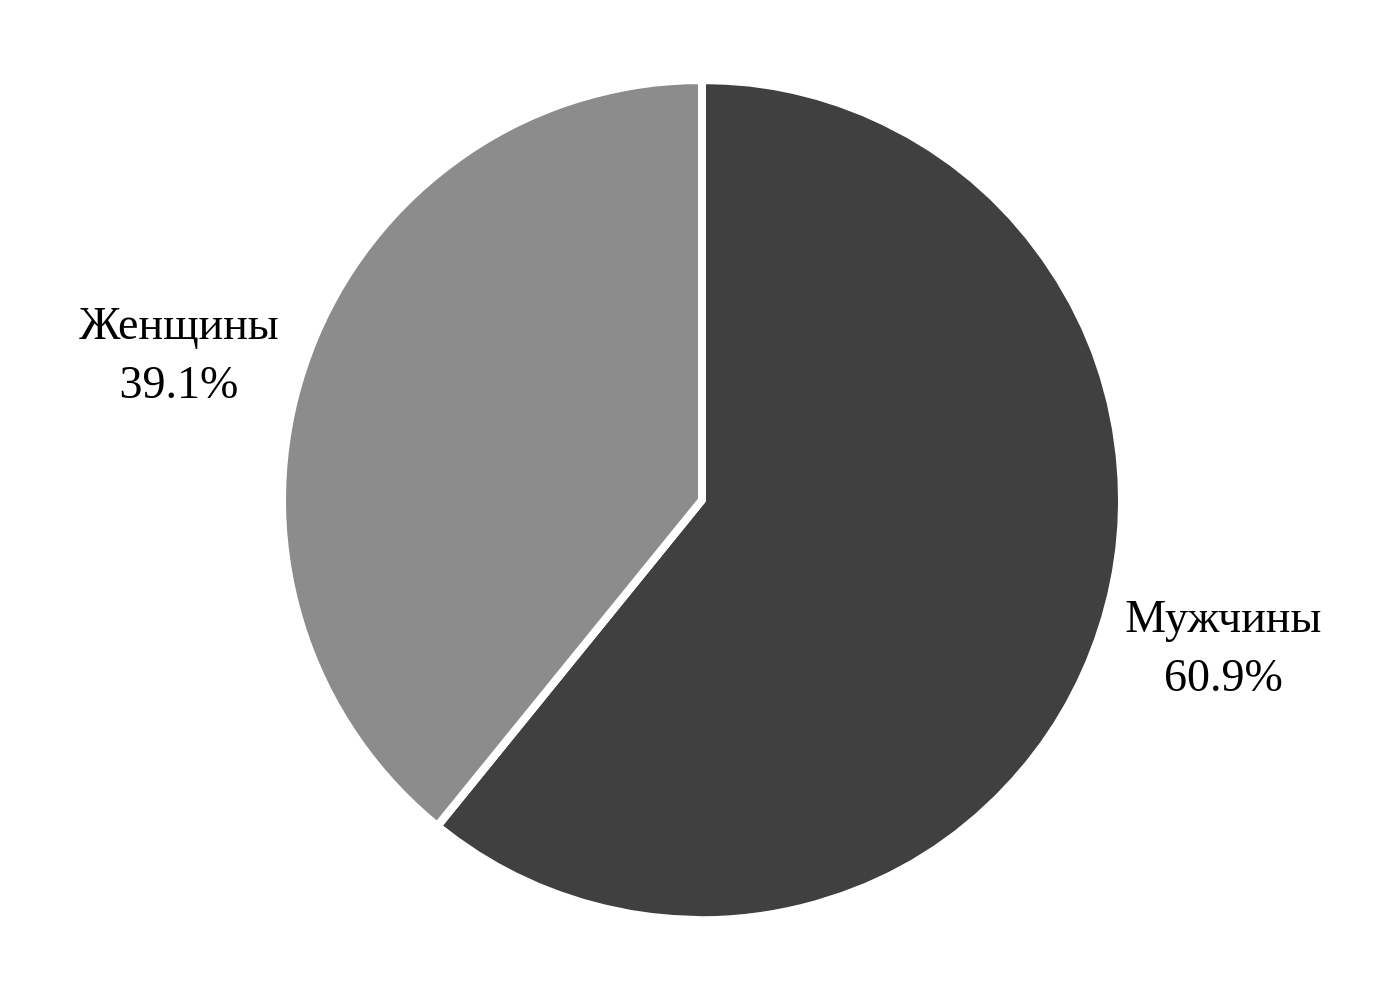

In [2]:
gender_counts = df["Gender"].value_counts()

gender_ru = {
    'Male': 'Мужчины',
    'Female': 'Женщины'
}
labels = [gender_ru.get(x, x) for x in gender_counts.index]

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=gender_counts.values,
    marker=dict(
        colors=[PRIMARY, ACCENT],
        line=dict(color='white', width=4)
    ),
    textposition='outside',
    textinfo='label+percent',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Количество: %{value} чел.<br>'
        'Доля: %{percent}'
        '<extra></extra>'
    )
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    margin=dict(l=40, r=40, t=40, b=40)
)

fig.show()

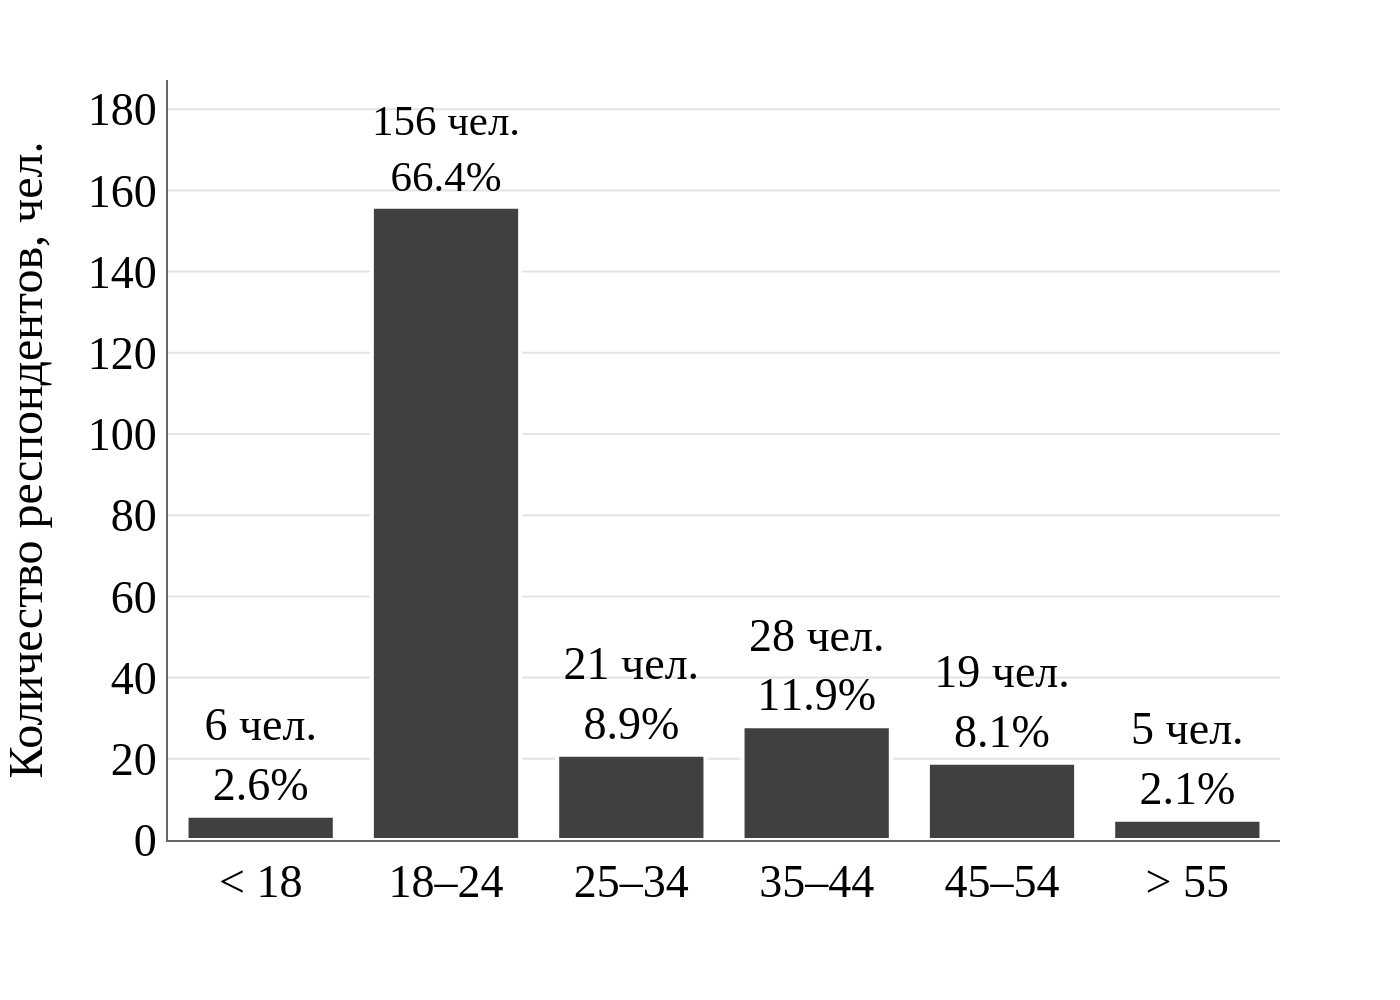

In [3]:
age_order = ["Less than 18", "18-24", "25-34", "35-44", "45-54", "More than 55"]
age_counts = df["Age (in years)"].value_counts().reindex(age_order)
age_percent = (age_counts / age_counts.sum() * 100).round(1)

age_ru = {
    "Less than 18": "< 18",
    "18-24": "18–24",
    "25-34": "25–34",
    "35-44": "35–44",
    "45-54": "45–54",
    "More than 55": "> 55"
}
labels = [age_ru[age] for age in age_counts.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=age_counts.values,
    text=[f'{count} чел.<br>{pct}%' for count, pct in zip(age_counts.values, age_percent.values)],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x} лет</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, age_counts.max() * 1.2]
    ),
    margin=dict(l=60, r=60, t=40, b=60)
)

fig.show()

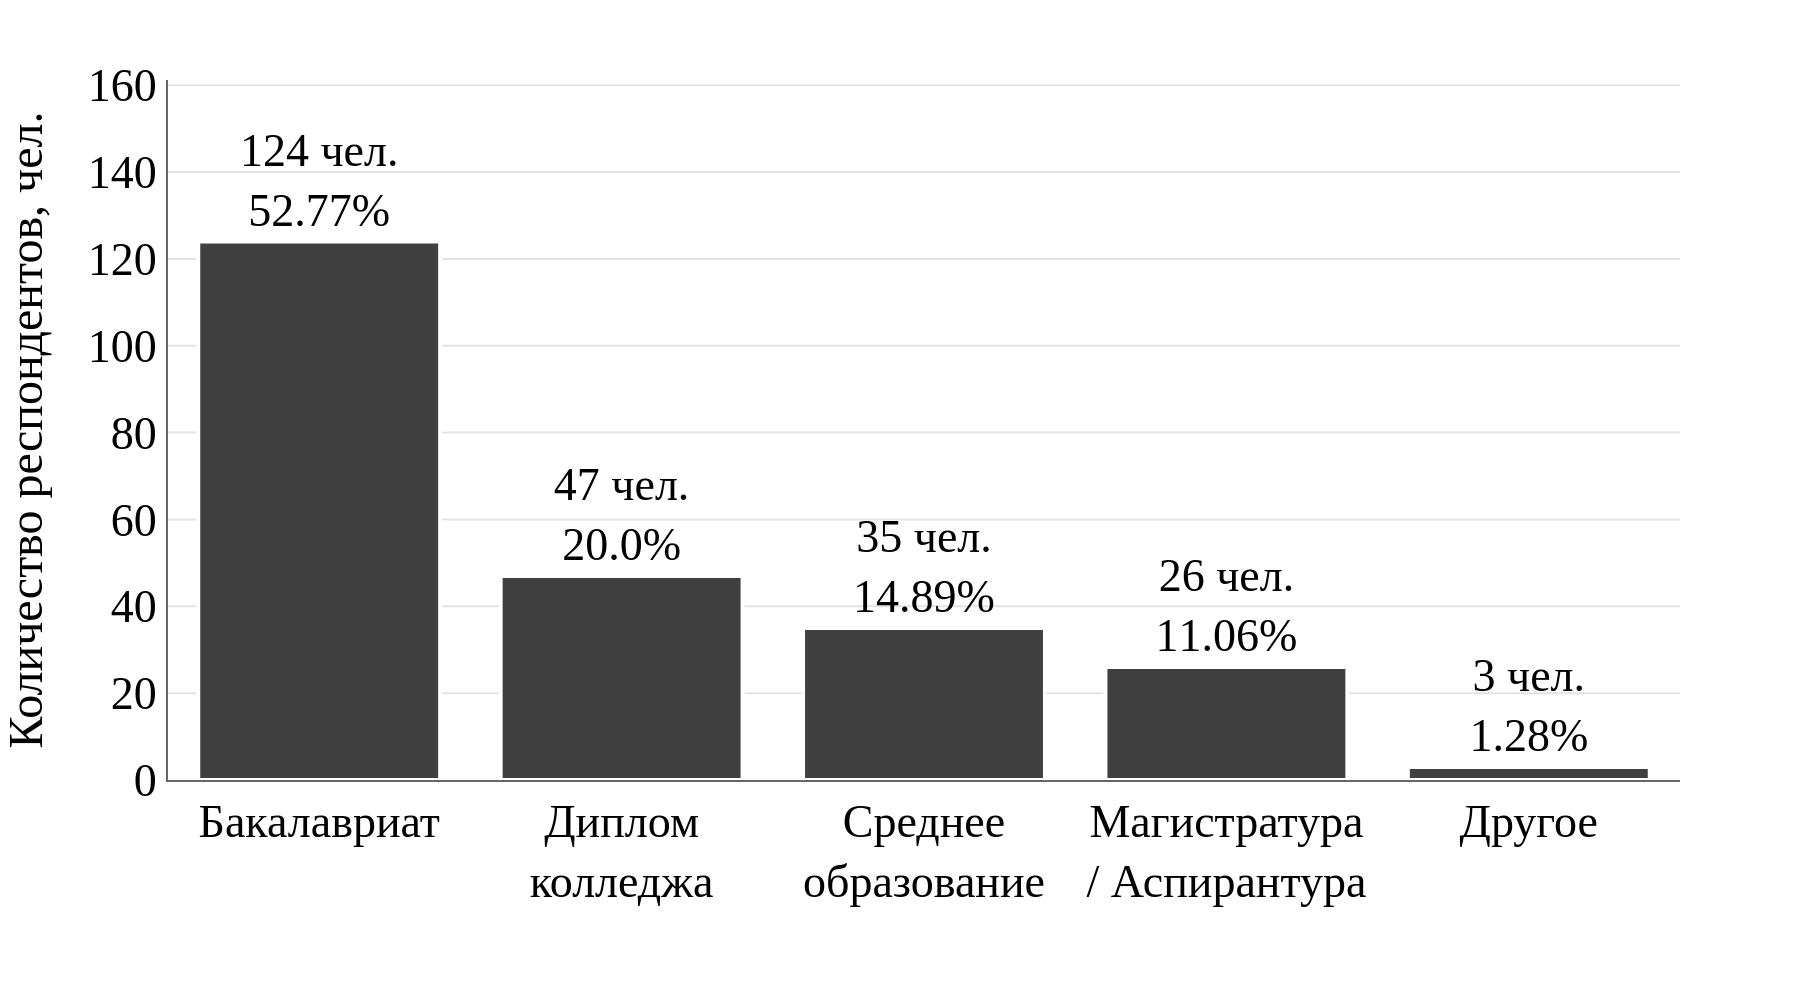

In [4]:
edu_col = "What is the highest level of education you have completed?"
edu_counts = df[edu_col].value_counts()
edu_percent = (edu_counts / edu_counts.sum() * 100).round(2)

edu_ru = {
    'High school': 'Среднее<br>образование',
    'Trade school': 'Профессиональное<br>училище',
    'College diploma / Certificate': 'Диплом<br>колледжа',
    'Undergraduate degree': 'Бакалавриат',
    'Masters / Post-Graduate degree': 'Магистратура<br>/ Аспирантура',
    'Postgraduate degree': 'Магистратура<br>/ Аспирантура',
    'Other': 'Другое'
}

labels = [edu_ru.get(x, x) for x in edu_counts.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=edu_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(edu_counts.values, edu_percent.values)
    ],
    textposition='outside',
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        tickangle=0,
        linewidth=1
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, edu_counts.max() * 1.3]
    ),
    margin=dict(l=60, r=60, t=40, b=110),
    width=900
)

fig.show()
